In [1]:
import numpy as np
import pandas as pd
import cooler

import matplotlib.pyplot as plt
from tqdm import tqdm, trange

from itertools import combinations
import pybedtools

from genomic_regions import as_region

import math

import matplotlib.pyplot as plt
import networkx as nx
import random

plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

### 找两个例子突出SGMCI的准确性：(或者4个: 主图2个附件2个)
&emsp;&emsp;---- MATCHA预测为是，而SGMCI预测为否（同时无表观信号对应）\
&emsp;&emsp;---- MATCHA预测为否，而SGMCI预测为是（同时有表观信号对应）

In [3]:
#### HiPore-C GM12878 1Mb Unobserved_MCI_O3: SGMCI vs MATCHA

Unobserved_MCI_O3 = np.load('/data/xujs/Project/HiC2PoreC/code/SGMCI/Analysis_Results/2024-05-23_Predict_New_MCI/HiPore-C_GM12878_1Mb.Unobserved_MCI_O3.npy')
SGMCI_O3_preds_score = np.load('/data/xujs/Project/HiC2PoreC/code/SGMCI/Analysis_Results/2024-05-23_Predict_New_MCI/HiPore-C_GM12878_1Mb.Unobserved_MCI_O3_pred_score.npy').reshape(-1)
matcha_O3_preds_score = np.load('/data/xujs/Project/HiC2PoreC/code/SGMCI/Analysis_Results/2024-05-31_Model_comparison/MATCHA/1Mb_Code/HiPore-C_GM12878_1Mb.MATCHA_Unobserved_MCI_O3_pred_score.npy').reshape(-1)

In [7]:
(SGMCI_O3_preds_score >= 0.5) & (matcha_O3_preds_score >= 0.5)

array([False, False, False, ..., False, False, False])

In [8]:
Unobserved_MCI_O3[(SGMCI_O3_preds_score >= 0.5) & (matcha_O3_preds_score >= 0.5)].shape

(105966, 3)

In [4]:
## MATCHA预测为否，而SGMCI预测为是
Unobserved_MCI_O3_is_SGMCI_not_matcha = Unobserved_MCI_O3[(matcha_O3_preds_score < 0.5) & (SGMCI_O3_preds_score >= 0.5) ]

## MATCHA预测为是，而SGMCI预测为否
Unobserved_MCI_O3_is_matcha_not_SGMCI = Unobserved_MCI_O3[(matcha_O3_preds_score >= 0.5) & (SGMCI_O3_preds_score < 0.5) ]

In [10]:
### 得到具体概率值
mcis = Unobserved_MCI_O3[(matcha_O3_preds_score < 0.5) & (SGMCI_O3_preds_score >= 0.5)]
mcis = mcis.tolist()
mcis_SGMCI_score = SGMCI_O3_preds_score[(matcha_O3_preds_score < 0.5) & (SGMCI_O3_preds_score >= 0.5) ]
mcis_matcha_score = matcha_O3_preds_score[(matcha_O3_preds_score < 0.5) & (SGMCI_O3_preds_score >= 0.5) ]

In [ ]:
Repliseq_file = '/data/xujs/Public_Data/Repli-seq/hg38/GM12878/GM12878.Repli-seq.E2L_log2.1Mb.hg38.bedGraph'
Subcompartment_file = '/data/xujs/Project/HiC2PoreC/code/SGMCI/Analysis_Results/2024-05-06_embedding_visualization/liftOver_hg19_to_hg38/GSE63525_GM12878_subcompartments.hg19_to_hg38.1Mb.bed'
SuperEnhancer_file = '/data/xujs/References/human/hg38/SuperEnhancer/GM12878.SE.hg38_1Mb.bed'

# bedtools intersect -a ../hg38_windows/hg38.window_1Mb.bed -b GM12878.SE.hg38.bed -wa -wb | awk '{print $1,$2,$3}' >GM12878.SE.hg38_1Mb.bed

In [ ]:
df_Repliseq = pd.read_table(Repliseq_file, sep='\t', header=None, names=['chrom', 'start', 'end', 'score'])
df_Repliseq = df_Repliseq.loc[~(df_Repliseq.end - df_Repliseq.start > 1000000)]
df_Repliseq = df_Repliseq.loc[~df_Repliseq.chrom.isin(["chrX", "chrY", "chrM"])]

df_Subcompartment = pd.read_table(Subcompartment_file, sep='\t', header=None).iloc[:, :4]
df_Subcompartment.columns =['chrom', 'start', 'end', 'subcompartment_type']

df_SuperEnhancer = pd.read_table(SuperEnhancer_file, sep=' ', header=None).iloc[:, :3]
df_SuperEnhancer.columns = ['chrom', 'start', 'end']
df_SuperEnhancer = df_SuperEnhancer.drop_duplicates()
df_SuperEnhancer['SE_type'] = 1
df_SuperEnhancer = df_SuperEnhancer.loc[~df_SuperEnhancer.chrom.isin(["chrX", "chrY", "chrM"])]

## 1Mb window
df_hg38_1Mb = pd.read_table('/data/xujs/References/human/hg38/hg38_windows/hg38.window_1Mb.bed', header=None)
df_hg38_1Mb.columns = ['chrom', 'start', 'end']
df_hg38_1Mb = df_hg38_1Mb.loc[~df_hg38_1Mb.chrom.isin(["chrX", "chrY", "chrM"])]

In [ ]:
subcompartment_dict = {}
superenhancer_dict = {}
repliseq_dict = {}

for index, row in df_hg38_1Mb.iterrows():
    bin = f'{row["chrom"]}:{row["start"]}'
    # node = bin2node[bin]
    subcompartment_dict[bin] = 0
    superenhancer_dict[bin] = 0
    repliseq_dict[bin] = 0

for index, row in df_Subcompartment.iterrows():
    bin = f'{row["chrom"]}:{row["start"]}'
    subcompartment_dict[bin] = row['subcompartment_type']

for index, row in df_SuperEnhancer.iterrows():
    bin = f'{row["chrom"]}:{row["start"]}'
    superenhancer_dict[bin] = row['SE_type']

for index, row in df_Repliseq.iterrows():
    bin = f'{row["chrom"]}:{row["start"]}'
    repliseq_dict[bin] = row['score']

In [64]:
node2bin = np.load('/data/xujs/Project/DeepLearning/MCIP/Results/preprocess_results/hg38.1000kb.node2bin.npy', allow_pickle=True).item()
node2bin = {k-1:v for k,v in node2bin.items()}
bin2node = {v:k for k,v in node2bin.items()}

node2chrom = np.load(f"/data/xujs/Project/DeepLearning/MCIP/Results/preprocess_results/hg38.1000kb.node2chrom.npy", allow_pickle=True).item()
node2chrom = {k-1:v for k,v in node2chrom.items()}

data_dir = '/data/xujs/Project/DeepLearning/MCIP/Results'
chrom_range_ = np.load(f"{data_dir}/preprocess_results/hg38.1000kb.chrom_range.npy")
chrom_range = {}
for x in chrom_range_:
    chrom_range[x[0]] = np.array([int(x[1])-1, int(x[2])-1])

node_num = len(node2bin)

In [ ]:
### 要求预测的MCI：
#       1) Subcompartment属于相同/相似
#       2）Repliseq相同
#       3）至少一个node有superEnhancer.

mci_infos =[] 
for mci in tqdm(Unobserved_MCI_O3_is_SGMCI_not_matcha):
    mci_info = []
    mci_info += ['-'.join([f'{x}' for x in mci])]
    for node in mci:
        bin = node2bin[node]

        if bin.split(':')[0] == 'chrX':
            break

        node_subcompartment = subcompartment_dict[bin]
        node_superenhancer = superenhancer_dict[bin]
        node_repliseq = repliseq_dict[bin]
        mci_info += [bin, node_subcompartment, node_superenhancer, node_repliseq]

    mci_infos.append(mci_info)

df_result = pd.DataFrame(mci_infos, columns=['mci',
                                'n1', 'n1_subcompartment', 'n1_SE', 'n1_RepliSeq',
                                'n2', 'n2_subcompartment', 'n2_SE', 'n2_RepliSeq',
                                'n3', 'n3_subcompartment', 'n3_SE', 'n3_RepliSeq'])
df_result = df_result.dropna()

In [ ]:
## 第一步过滤
df_result_filter1 = df_result.loc[
                ((df_result.n1_subcompartment.isin(['A1', 'A2'])) & df_result.n2_subcompartment.isin(['A1', 'A2']) & df_result.n3_subcompartment.isin(['A1', 'A2'])) & 
                ((df_result.n1_SE == 1) | (df_result.n2_SE == 1) | (df_result.n3_SE == 1)) &
                ((df_result.n1_RepliSeq > 0) & (df_result.n2_RepliSeq > 0) & (df_result.n3_RepliSeq > 0))
                ]

In [ ]:
## 保留scHi-C edges支持的MCI.
import glob
scool_data_dir = '/data/xujs/Project/HiC2PoreC/code/SGMCI/Analysis_Results/2024-05-20_scHi-C/hg19_scool/hg19_to_hg38_scool'
GM12878_scHiC_files = glob.glob(f'{scool_data_dir}/*GM12878*mcool')

# cool = cooler.Cooler(f'{scool_data_dir}/ramani_10kb_human_8973_GM12878_AAGCGACC-GCCATTAA_10000.matrix.hg19_to_hg38.mcool::resolutions/1000000')

def extract_hic_wg_mat(mcool_file):
    cool = cooler.Cooler(f'{mcool_file}::resolutions/1000000')
    wg_mat = np.zeros((node_num, node_num)) # whole genome mat.

    for chrom1, range1 in chrom_range.items():
        s1, e1 = range1
        for chrom2, range2 in chrom_range.items():
            s2, e2 = range2
            mat = cool.matrix(balance=False, sparse=False).fetch(chrom1, chrom2)
            wg_mat[s1:e1, s2:e2] = mat
        
    return wg_mat


scHiC_matrices = []
for scHiC_file in tqdm(GM12878_scHiC_files):
    wg_mat = extract_hic_wg_mat(mcool_file=scHiC_file)
    scHiC_matrices.append(wg_mat)

## 保留scHi-C edges支持的MCI.

def stat_schic_edge(data):

    schic_edge_list = []

    for mci in data:
        decomposed_edges = list(combinations(mci, 2))
        n = 0
        for edge in decomposed_edges:
            for schic_mat in scHiC_matrices:
                contact_freq = schic_mat[edge[0], edge[1]]
                if contact_freq:
                    n += 1
                    break
                else:
                    continue
        if n == 3:
            schic_edge_list.append(1)
        else:
            schic_edge_list.append(0)

    schic_edge_list = np.array(schic_edge_list)

    return schic_edge_list

In [ ]:
filter1_MCI = np.array([[int(i) for i in x.split('-')] for x in df_result_filter1.mci.tolist()])
filter1_MCI_schic_stat = stat_schic_edge(filter1_MCI)
filter2_MCI = filter1_MCI[filter1_MCI_schic_stat == 1]  ## 第二步过滤：保留schic支持的3way-MCI.
df_result_filter2 = df_result_filter1.loc[df_result_filter1.mci.isin(['-'.join([str(i) for i in x]) for x in filter2_MCI])]
df_result_filter2.to_csv('./Unobserved_MCI_O3_is_SGMCI_not_matcha_f1_se_f2_schic.csv', index=False, sep=',')

In [5]:
df_result_filter2 = pd.read_csv('./Unobserved_MCI_O3_is_SGMCI_not_matcha_f1_se_f2_schic.csv')

In [ ]:
tf_peak_file_dir = '/data/xujs/Public_Data/ENCODE_Data/human/hg38/GM12878/TF-ChIP-seq/bed_peak'
hm_peak_file_dir = '/data/xujs/Public_Data/ENCODE_Data/human/hg38/GM12878/Histone-ChIP-seq/bed_peak'

In [ ]:
# tf_peak = pybedtools.BedTool('/data/xujs/Public_Data/ENCODE_Data/human/hg38/GM12878/TF-ChIP-seq/bed_peak/GM12878.ZNF24.ENCFF664TYB.GRCh38.narrowPeak.bed')
# bin = pybedtools.BedTool('chr1 116000000 117000000', from_string=True)

# res = bin.intersect(tf_peak, u=True)

In [ ]:
import os

tf_peak_files = glob.glob(f'{tf_peak_file_dir}/*Peak.bed')

mci_peak_dict = {}

for tf_peak_file in tf_peak_files:
    tf_name = os.path.basename(tf_peak_file).split('.')[1]
    mci_peak_dict[tf_name] = []

bin_size = 1000000
for mci in tqdm(filter2_MCI[:10]):
    for tf_peak_file in tf_peak_files:
        tf_name = os.path.basename(tf_peak_file).split('.')[1]
        tf_peak = pybedtools.BedTool(tf_peak)
        i = 0
        for node in mci:
            bin = node2bin[node]
            chrom, start = bin.split(':')
            start = int(start)
            end = start + bin_size
            new_bin = pybedtools.BedTool(f'{chrom} {start} {end}', from_string=True)
            res = new_bin.intersect(tf_peak, u=True)
            if len(res):
                i += 1

        mci_peak_dict[tf_name].append(i)

In [ ]:
## mci node内部的基因

hg38_gene_file = '/data/xujs/References/human/hg38/hg38.gene.bed'

bin_size = 1000000
for mci in tqdm(filter2_MCI[:10]):

    # hg38_gene = os.path.basename(tf_peak_file).split('.')[1]
    hg38_gene = pybedtools.BedTool(hg38_gene_file)
    i = 0
    for node in mci:
        bin = node2bin[node]
        chrom, start = bin.split(':')
        start = int(start)
        end = start + bin_size
        new_bin = pybedtools.BedTool(f'{chrom} {start} {end}', from_string=True)
        res = new_bin.intersect(tf_peak, u=True)
        if len(res):
            i += 1

    # mci_peak_dict[tf_name].append(i)

In [ ]:
## FAN-C track visualization.

import numpy as np
import pandas as pd
import datatable as dt
import gc

import seaborn as sns

import matplotlib.pyplot as plt
sns.set_color_codes("pastel")
import matplotlib as mpl
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.patches import ConnectionPatch
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.patches import Arc, Polygon, Rectangle
from intervaltree import Interval, IntervalTree
import pybedtools
import tempfile
import sys, os
import math

import fanc
import fanc.plotting as fancplot
from genomic_regions import GenomicRegion, as_region

def get_region(region):
    chrom, pos = region.split(':')
    start, end = pos.split('-')
    return chrom, int(start), int(end)

class InputError(Exception):
    "Exception raised for errors in the input."
    pass

def process_link_file(link_file, plot_regions):

    if plot_regions is None:
        file_to_open = link_file
    else:
        plot_regions_adapted = [(chrom, 0, int(3e8)) for chrom, __, __ in plot_regions]
        file_to_open = temp_file_from_intersect(link_file, plot_regions_adapted)

    interval_tree = {}
    line_number = 0
    with open(file_to_open, 'r') as f:
        for line in f:
            line_number += 1
            if line.startswith('#'):
                continue
            try:
                chrom1, start1, end1, chrom2, start2, end2 = line.strip().split('\t')[:6]
            except Exception as detail:
                raise InputError('File not valid. The file format should be'
                                f'chrom1 start1 end1 chrom2 start2 end2\n Error: {detail}\n'
                                f' in line\n {line}')
            if chrom1 != chrom2:
                continue

            start1, end1, start2, end2 = int(start1), int(end1), int(start2), int(end2)
            
            assert start1 <= end1, f'Error in line #{line_number}, end1 larger than start1 in {line}'
            assert start2 <= end2, f'Error in line #{line_number}, end2 larger than start2 in {line}'

            if chrom1 not in interval_tree:
                interval_tree[chrom1] = IntervalTree()
            
            if start2 < start1:
                start1, start2 = start2, start1
                end1, end2 = end2, end1
            
            mid1 = (start1 + end1) / 2
            mid2 = (start2 + end2) / 2
            interval_tree[chrom1].add(Interval(mid1, mid2, [start1, end1, start2, end2]))
    return interval_tree

def temp_file_from_intersect(filename, plot_regions=None, around_region=0):
    """
    intersect filename with the plot_regions +/- around_region.
    :param filename: string file name.
    :param plot_regions: a list of tuple [(chrom1, start1, end1), (chrom2, start2, end2)]
    :param around_region: integer with the bo to extend the plot_region.
    :return: tmoporary file with the intersection.
    """
    file_to_open = filename
    if plot_regions is not None:
        original_file = pybedtools.BedTool(filename)
        plot_regions_ext = [(chrom, int(max(1, start-around_region)), int(end+around_region)) for chrom, start, end in plot_regions]
        ### overlap both version of chromosome name (with/without chr)
        plot_regions_as_bed = '\n'.join([f'{chrom}\t{start}\t{end}\n{change_chrom_names(chrom)}\t{start}\t{end}' for chrom, start, end in plot_regions_ext])
        regions = pybedtools.BedTool(plot_regions_as_bed, from_string=True)
        temporary_file = tempfile.NamedTemporaryFile(delete=False)
        sys.stderr = open(temporary_file.name, 'w')

        try:
            file_to_open = original_file.intersect(regions, wa=True, u=True).fn
            # print(file_to_open)
        except pybedtools.helpers.BEDToolsError:
            file_to_open = filename
            # print(f'===>{file_to_open}')
        sys.stderr.close()
        sys.stderr = sys.__stderr__
        with open(temporary_file.name, 'r') as f:
            temd_std_error = f.readlines()
        os.remove(temporary_file.name)
        error_lines = [line for line in temd_std_error if 'error' in line.lower()]
        if len(error_lines) >0:
            error_lines_printable = '\n'.join(error_lines)
            sys.stderr.write('Bedtools intersect raised an error:\n'
                             f"{error_lines_printable}\n"
                             "Will not use bedtools.\n")
            file_to_open = filename
    return file_to_open


def change_chrom_names(chrom):
    if chrom.startswith('chr'):
        chrom = chrom[3:]
    else:
        chrom = 'chr' + chrom

    return chrom


def plot_arcs(ax, interval, color='#C5479B', compact_arcs_level=1):
    width = interval.end - interval.begin
    if compact_arcs_level == 1: ## the height is propotional to the square root of the distance.
        half_height = np.sqrt(width)
    elif compact_arcs_level == 2:  ## the height is the same for all distance.
        half_height = 1000
    else:
        half_height = width
    center = interval.end - width / 2

    ax.add_patch(Arc((center, 0), width, 2*half_height, 
                      0, 0, 180, color=color, alpha=1,
                      linewidth=1, ls='solid'))


def check_chrom_str_bytes(iteratable_obj, p_obj):

    def to_string(s):
        """
        This takes care of python2/3 differences
        """
        if isinstance(s, str):
            return s
        if isinstance(s, bytes):
            assert(sys.version_info[0] != 2)
        #        if sys.version_info[0] == 2:
        #            return str(s)
            return s.decode('ascii')
        if isinstance(s, list):
            return [to_string(x) for x in s]
        return s

    def to_bytes(s):
        """
        Like toString, but for functions requiring bytes in python3
        """
        assert(sys.version_info[0] != 2)
    #    if sys.version_info[0] == 2:
    #        return s
        if isinstance(s, bytes):
            return s
        if isinstance(s, str):
            return bytes(s, 'ascii')
        if isinstance(s, list):
            return [to_bytes(x) for x in s]
        return s
    # determine type
    if isinstance(p_obj, list) and len(p_obj) > 0:
        type_ = type(p_obj[0])
    else:
        type_ = type(p_obj)
    if not isinstance(type(next(iter(iteratable_obj))), type_):
        if type(next(iter(iteratable_obj))) is str:
            p_obj = to_string(p_obj)
        elif type(next(iter(iteratable_obj))) in [bytes, np.bytes_]:
            p_obj = to_bytes(p_obj)
    return p_obj


def plot_loop(ax, interval_tree, region_chrom, region_start, region_end, ylabel=''):
    region_chrom = check_chrom_str_bytes(interval_tree, region_chrom)
    arcs_in_region = sorted(interval_tree[region_chrom][region_start:region_end])

    ## get ylim.
    if arcs_in_region:
        yvalues = [np.sqrt(interval.end - interval.begin) for interval in arcs_in_region ]
        ymax = math.ceil(np.percentile(yvalues, 90) / 100 + 1) * 100

        for idx, interval in enumerate(arcs_in_region):
            if interval.begin < region_start and interval.end >region_end:
                continue
            plot_arcs(ax, interval, compact_arcs_level=1)
    else:
        ymax = 0

    ax.set_xlim([region_start, region_end])
    Xtick = list( np.linspace(region_start, region_end, 5 ,endpoint=True) )
    Xtick_label = [ "%.3f"%(i/10**6) for i in Xtick ]
    ax.set_xticks(Xtick)
    # ax.set_ylim([ymax, 0])
    ax.set_ylim([0, ymax])
    ax.set_yticks([])
    ax.set_ylabel(ylabel)
    ## remove frame border.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(False)

def FancTrackLinePlot(filename, color, label, fill=True, ylabel=None, ylim=None, ax=None):
    track = fanc.load(filename)
    hp = fancplot.LinePlot(track, fill=fill, style='mid', colors=[color], labels=[label], ylabel=ylabel, ylim=ylim, n_yticks=2, ax=ax)
    return hp

def FancTrackBarPlot(filename, color, label, ylabel=None, ylim=None, ax=None):
    track = fanc.load(filename)
    hp = fancplot.BarPlot(track, style='step', colors=[color], labels=[label], ylabel=ylabel, ylim=ylim, n_yticks=2, ax=ax)
    return hp


def FancTrackRegionPlot(filename, color, ylabel=None, ax=None):
    track = fanc.load(filename)
    hp = fancplot.GenomicFeaturePlot(track, color=color, ylabel=ylabel, ax=ax)
    return hp

In [ ]:
#### 可视化

## 1. Hi-C heatmap
## 2. Repli-seq
## 3. Subcompartment
## 4. SuperEnhancer
## 5. SGMCI predicted 3way-MCI.

## 111-160-224 chr1:111000000-112000000  chr1:160000000-161000000  chr1:224000000-225000000

region = 'chr1:10000000-122000000'

# target_region = as_region(target_region)
region = as_region(region)

# resolution = 10000
fanc_region = f'{region.chromosome}:{(region.start/1000000):.2f}mb-{(region.end/1000000):.2f}mb'


fig, axes = plt.subplots(5, 1, figsize=(6, 4), constrained_layout=True,
                        gridspec_kw={'height_ratios': [0.4, 0.05, 0.05, 0.05, 0.1]})

def add_right_cax(ax, pad, width, bottom, height):
    '''
    在一个ax右边追加与之等高的cax.
    pad是cax与ax的间距.
    width是cax的宽度.
    '''
    axpos = ax.get_position()
    caxpos = mpl.transforms.Bbox.from_extents(
        axpos.x1 + pad,
        axpos.y0 + bottom,
        axpos.x1 + pad + width,
        axpos.y1 + height
    )
    cax = ax.figure.add_axes(caxpos)

    return cax


#  plot tracks: chr1:
axes = axes.flatten()

## set heatmap color.
cmap_classic = LinearSegmentedColormap.from_list('normal', [(1, 1, 1), (1, 0, 0)], N=1000)  # white -> red
cmap_diff = LinearSegmentedColormap.from_list('normal', [(0,0,1), (1,1,1), (1,0,0)], N=1000)  ## colormap: blue -> red
cmap_oe = LinearSegmentedColormap.from_list('normal', ['#1f2d5f', '#6d93bf', '#edf0f2', '#dba786', '#520c1c'], N=1000) 

## 1. GM12878 Hi-C
hic_file_dir = '/data/xujs/Project/HiPoreC_Promoter_Result/Result/2022-09-27_HiPoreC_to_cool_hic_files'
# hic_filename = f'{hic_file_dir}/GM12878.Merge.HiPoreC.mcool@1mb'
hic_filename = f'{hic_file_dir}/GM12878.Merge.HiPoreC.hic@1mb'
hic = fanc.load(hic_filename)
# HiC_plot = fancplot.TriangularMatrixPlot(hic, vmin=0, vmax=10000, max_dist=region.end - region.start, colormap=cmap_diff, show_colorbar=True, ax=axes[0])
HiC_plot = fancplot.TriangularMatrixPlot(hic, oe=True, vmin=0, vmax=3, colormap=cmap_oe, show_colorbar=False, ax=axes[0])
HiC_plot.plot('1:10mb-122mb')
# cax = add_right_cax(axes[0], pad=0.065, width=0.015, bottom=0.09, height=0.09)
# norm = mpl.colors.Normalize(vmin=0, vmax=50)
# cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_classic), cax=cax, label='Normalized counts')
axes[0].set_ylabel('Hi-C', rotation=0, x=-0.1, y=0.3)

## 2. Repli-seq bw
# filename = f'/data/xujs/Public_Data/Repli-seq/hg38/GM12878/GM12878.Repli-seq.E2L_log2.1Mb.hg38.bw'
filename = f'/data/xujs/Public_Data/Repli-seq/hg38/GM12878/GM12878.Repli-seq.E2L_log2.hg38.bw'
p3 = FancTrackLinePlot(filename, '#d14b9d', 'Repli-seq"', True, "Repli-seq", ylim=(-2, 2), ax=axes[1])
p3.plot(fanc_region)
axes[1].set_ylabel('Repli-seq           ', rotation=0, x=-0.1, y=0.3)

## 3. Subcompartment bed
filename = f'/data/xujs/Project/HiC2PoreC/code/SGMCI/Analysis_Results/2024-05-06_embedding_visualization/liftOver_hg19_to_hg38/GSE63525_GM12878_subcompartments.hg19_to_hg38.1Mb.bed'

subcompartment = pybedtools.BedTool(filename)
region_ = pybedtools.BedTool(f'{region.chromosome} {region.start} {region.end}', from_string=True)
region_subcompartment_anno = region_.intersect(subcompartment, wa=True, wb=True, output='tmp')
region_subcompartment_anno = pd.read_table('tmp', names=['region_chrom', 'region_start', 'region_end', 'sub_chrom', 'sub_start', 'sub_end', 'sub_type'])

subcompartment_label_colors = {'A1': '#9b2025', 'A2': '#dea728', 'B1': '#a5a397', 'B2': '#7581cb', 'B3': '#7e6481', 'B4': '#3b8eea'}
for index, row in region_subcompartment_anno.iterrows():
    # print(index)
    sub_type = row['sub_type']
    start, end = int(row['sub_start']), int(row['sub_end'])

    if sub_type in ['B4', 'X']:
        continue

    xs = [start, end]
    ys = [0, 0.0]
    axes[2].add_patch(Rectangle((start, 0.5), width=end-start, height=0.2, color=subcompartment_label_colors[sub_type]))

Xtick = list( np.linspace(region.start, region.end, 5, endpoint=True) )
Xtick_label = [ "%.3f"%(i/10**6) for i in list( np.linspace(region.start, region.end, 5 ,endpoint=True) ) ]
axes[2].set_xlim([region.start, region.end])
axes[2].set_xticks(Xtick)
axes[2].set_xticklabels(Xtick_label)
axes[2].set_ylabel('Subcompartments                         ', rotation=0, x=-0.1, y=0.3)

## 4. SuperEnhancer bed
filename = f'/data/xujs/References/human/hg38/SuperEnhancer/GM12878.SE.hg38_1Mb.bed'
SE = pybedtools.BedTool(filename)
region_SE_anno = region_.intersect(SE, wa=True, wb=True, output='tmp')
region_SE_anno = region_.intersect(SE, wa=True, wb=True, output='tmp')
region_SE_anno = pd.read_table('tmp', names=['region_chrom', 'region_start', 'region_end', 'se_chrom', 'se_start', 'se_end'])

for index, row in region_SE_anno.iterrows():
    # print(index)
    start, end = int(row['se_start']), int(row['se_end'])
    xs = [start, end]
    ys = [0, 0.0]
    axes[3].add_patch(Rectangle((start, 0.5), width=end-start, height=0.2, color='black'))

Xtick = list( np.linspace(region.start, region.end, 5, endpoint=True) )
Xtick_label = [ "%.3f"%(i/10**6) for i in list( np.linspace(region.start, region.end, 5 ,endpoint=True) ) ]
axes[3].set_xlim([region.start, region.end])
axes[3].set_xticks(Xtick)
axes[3].set_xticklabels(Xtick_label)
axes[3].set_ylabel('SE         ', rotation=0, x=-0.1, y=0.3)

## 5. SGMCI predicted 3-way MCI.
MCIs = np.array([[15, 54, 116],
                 [15, 53, 116]])

bin_size = 1000000
y = 0
for mci in MCIs:
    axes[4].plot([region.start, region.end], [y, y], color='#bebebe', linewidth=1)  ##灰色横线
    for node in mci:
        bin = node2bin[node]
        chrom, start = bin.split(':')
        start = int(start)
        end = start + bin_size
        bin_region = as_region(f'{chrom}:{start}-{end}')
        x = bin_region.center
        axes[4].plot(x, y, 'o', color='#d16f62', markersize=5)
    y += 1

Xtick = list( np.linspace(region.start, region.end, 5, endpoint=True) )
Xtick_label = [ "%.3f"%(i/10**6) for i in list( np.linspace(region.start, region.end, 5 ,endpoint=True) ) ]
axes[4].set_xlim([region.start, region.end])
axes[4].set_ylim([y-3, y])
axes[4].set_xticks(Xtick)
axes[4].set_xticklabels(Xtick_label)
axes[4].set_ylabel('MCI          ', rotation=0, x=-0.1, y=0.3)

for ax in axes[:-1]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['right'].set_visible(False) ## 去除边框
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

Xticks = list(np.linspace(region.start, region.end, 5, endpoint=True))
Xtick_label = [ "%.3f"%(i/10**6) for i in list( np.linspace(region.start, region.end, 5 ,endpoint=True) ) ]
axes[0].set_title(region)
axes[-1].set_xlim([region.start, region.end])
axes[-1].set_xticks(Xticks)
axes[-1].set_xticklabels(Xtick_label)
axes[-1].set_xlabel(region.chromosome)
axes[-1].set_yticks([])
axes[-1].spines['right'].set_visible(False) ## 去除边框
axes[-1].spines['top'].set_visible(False)
axes[-1].spines['left'].set_visible(False)
fig.savefig(f'{region}.tracks.pdf', bbox_inches = 'tight', dpi=300)

In [7]:
def get_bin_pos(node, bin_size=1000000):
    '''
    mci: i.e., (111, 160, 224)
    '''
    bin = node2bin[node]
    chrom, start = bin.split(':')
    start = int(start)
    end = start + bin_size
    bin_region = as_region(f'{chrom}:{start}-{end}')
    return bin_region

def find_surround_arr(target_array, data_array, s=1):
    '''
    对于target_array中的每个节点元素,找到周围相距s个bin以内的mci
    如: target_array: [15, 54, 116]
        [15, 53, 116]符合条件
    '''
    n1_s = np.arange(target_array[0]-s, target_array[0]+s+1)
    n2_s = np.arange(target_array[1]-s, target_array[1]+s+1)
    n3_s = np.arange(target_array[2]-s, target_array[2]+s+1)

    target_s_arr = [(x,y,z) for x in n1_s for y in n2_s for z in n3_s]

    return [x for x in data_array if x in target_s_arr]


mci_filter2 = np.array([[int(i) for i in x.split('-')] for x in df_result_filter2.mci.tolist()])
mci_filter2 = [tuple(x) for x in mci_filter2]

selected_mcis = []
for mci in mci_filter2:
    target_s_arr = find_surround_arr(mci, mci_filter2, s=1)
    if len(target_s_arr)>1:
        selected_mcis.append(target_s_arr)

selected_mcis = [list(t) for t in set(tuple(_) for _ in selected_mcis)]

In [ ]:
#### 可视化

## 1. Hi-C heatmap
## 2. Repli-seq
## 3. Subcompartment
## 4. SuperEnhancer
## 5. SGMCI predicted 3way-MCI.

## 111-160-224 chr1:111000000-112000000  chr1:160000000-161000000  chr1:224000000-225000000

def plot_mci_track(target_mci, region, bin_size=1000000):
    """
    region: 
    """
    # target_mci = [111, 160, 224]
    region = as_region(region)
    hic_region = f'{region.chromosome.replace("chr", "")}:{(region.start/bin_size):.2f}mb-{(region.end/bin_size):.2f}mb'  ## hic_region = '1:100mb-230mb'
    fanc_region = f'{region.chromosome}:{(region.start/bin_size):.2f}mb-{(region.end/bin_size):.2f}mb'


    def add_right_cax(ax, pad, width, bottom, height):
        '''
        在一个ax右边追加与之等高的cax.
        pad是cax与ax的间距.
        width是cax的宽度.
        '''
        axpos = ax.get_position()
        caxpos = mpl.transforms.Bbox.from_extents(
            axpos.x1 + pad,
            axpos.y0 + bottom,
            axpos.x1 + pad + width,
            axpos.y1 + height
        )
        cax = ax.figure.add_axes(caxpos)

        return cax

    #  plot tracks ...
    fig, axes = plt.subplots(5, 1, figsize=(6, 4), constrained_layout=True,
                            gridspec_kw={'height_ratios': [0.4, 0.05, 0.05, 0.05, 0.1]})
    axes = axes.flatten()

    ## set heatmap color.
    # cmap_classic = LinearSegmentedColormap.from_list('normal', [(1, 1, 1), (1, 0, 0)], N=1000)  # white -> red
    # cmap_diff = LinearSegmentedColormap.from_list('normal', [(0,0,1), (1,1,1), (1,0,0)], N=1000)  ## colormap: blue -> red
    cmap_oe = LinearSegmentedColormap.from_list('normal', ['#1f2d5f', '#6d93bf', '#edf0f2', '#dba786', '#520c1c'], N=1000) 

    ## 1. GM12878 Hi-C
    hic_file_dir = '/data/xujs/Project/HiPoreC_Promoter_Result/Result/2022-09-27_HiPoreC_to_cool_hic_files'
    # hic_filename = f'{hic_file_dir}/GM12878.Merge.HiPoreC.mcool@1mb'
    hic_filename = f'{hic_file_dir}/GM12878.Merge.HiPoreC.hic@1mb'
    hic = fanc.load(hic_filename)
    # HiC_plot = fancplot.TriangularMatrixPlot(hic, vmin=0, vmax=10000, max_dist=region.end - region.start, colormap=cmap_diff, show_colorbar=True, ax=axes[0])
    HiC_plot = fancplot.TriangularMatrixPlot(hic, oe=True, vmin=0, vmax=3, colormap=cmap_oe, show_colorbar=False, ax=axes[0])
    HiC_plot.plot(hic_region)
    # cax = add_right_cax(axes[0], pad=0.065, width=0.015, bottom=0.09, height=0.09)
    # norm = mpl.colors.Normalize(vmin=0, vmax=50)
    # cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_classic), cax=cax, label='Normalized counts')
    axes[0].set_ylabel('Hi-C', rotation=0, x=-0.1, y=0.3)

    ## 2. Repli-seq bw
    # filename = f'/data/xujs/Public_Data/Repli-seq/hg38/GM12878/GM12878.Repli-seq.E2L_log2.1Mb.hg38.bw'
    filename = f'/data/xujs/Public_Data/Repli-seq/hg38/GM12878/GM12878.Repli-seq.E2L_log2.hg38.bw'
    p3 = FancTrackLinePlot(filename, '#d14b9d', 'Repli-seq"', True, "Repli-seq", ylim=(-2, 2), ax=axes[1])
    p3.plot(fanc_region)
    axes[1].set_ylabel('Repli-seq           ', rotation=0, x=-0.1, y=0.3)

    ## 3. Subcompartment bed
    filename = f'/data/xujs/Project/HiC2PoreC/code/SGMCI/Analysis_Results/2024-05-06_embedding_visualization/liftOver_hg19_to_hg38/GSE63525_GM12878_subcompartments.hg19_to_hg38.1Mb.bed'
    subcompartment = pybedtools.BedTool(filename)
    region_ = pybedtools.BedTool(f'{region.chromosome} {region.start} {region.end}', from_string=True)
    region_subcompartment_anno = region_.intersect(subcompartment, wa=True, wb=True, output='tmp')
    region_subcompartment_anno = pd.read_table('tmp', names=['region_chrom', 'region_start', 'region_end', 'sub_chrom', 'sub_start', 'sub_end', 'sub_type'])

    subcompartment_label_colors = {'A1': '#9b2025', 'A2': '#dea728', 'B1': '#a5a397', 'B2': '#7581cb', 'B3': '#7e6481', 'B4': '#3b8eea'}
    for index, row in region_subcompartment_anno.iterrows():
        # print(index)
        sub_type = row['sub_type']
        start, end = int(row['sub_start']), int(row['sub_end'])

        if sub_type in ['B4', 'X']:
            continue

        xs = [start, end]
        ys = [0, 0.0]
        axes[2].add_patch(Rectangle((start, 0.5), width=end-start, height=0.2, color=subcompartment_label_colors[sub_type]))

    Xtick = list( np.linspace(region.start, region.end, 5, endpoint=True) )
    Xtick_label = [ "%.3f"%(i/10**6) for i in list( np.linspace(region.start, region.end, 5 ,endpoint=True) ) ]
    axes[2].set_xlim([region.start, region.end])
    # axes[2].set_xticks(Xtick)
    # axes[2].set_xticklabels(Xtick_label)
    axes[2].set_ylabel('Subcompartments                         ', rotation=0, x=-0.1, y=0.3)

    ## 4. SuperEnhancer bed
    filename = f'/data/xujs/References/human/hg38/SuperEnhancer/GM12878.SE.hg38_1Mb.bed'
    SE = pybedtools.BedTool(filename)
    region_SE_anno = region_.intersect(SE, wa=True, wb=True, output='tmp')
    region_SE_anno = region_.intersect(SE, wa=True, wb=True, output='tmp')
    region_SE_anno = pd.read_table('tmp', names=['region_chrom', 'region_start', 'region_end', 'se_chrom', 'se_start', 'se_end'])

    for index, row in region_SE_anno.iterrows():
        # print(index)
        start, end = int(row['se_start']), int(row['se_end'])
        xs = [start, end]
        ys = [0, 0.0]
        axes[3].add_patch(Rectangle((start, 0.5), width=end-start, height=0.2, color='black'))

    Xtick = list( np.linspace(region.start, region.end, 5, endpoint=True) )
    Xtick_label = [ "%.3f"%(i/10**6) for i in list( np.linspace(region.start, region.end, 5 ,endpoint=True) ) ]
    axes[3].set_xlim([region.start, region.end])
    # axes[3].set_xticks(Xtick)
    # axes[3].set_xticklabels(Xtick_label)
    axes[3].set_ylabel('SE         ', rotation=0, x=-0.1, y=0.3)

    ## 5. SGMCI predicted 3-way MCI.
    MCIs = find_surround_arr(target_mci, mci_filter2)

    y = 0
    for mci in MCIs:
        axes[4].plot([region.start, region.end], [y, y], color='#bebebe', linewidth=1)  ##灰色横线
        for node in mci:
            # bin = node2bin[node]
            bin_region = get_bin_pos(node)
            x = bin_region.center
            axes[4].plot(x, y, marker='o', color='#d16f62', markersize=4)
            # axes[4].scatter(x, y, marker='o', color='#d16f62', s=15)
        y += 1

    Xtick = list( np.linspace(region.start, region.end, 5, endpoint=True) )
    Xtick_label = [ "%.3f"%(i/10**6) for i in list( np.linspace(region.start, region.end, 5 ,endpoint=True) ) ]
    axes[4].set_xlim([region.start, region.end])
    axes[4].set_ylim([y-3, y])
    # axes[4].set_xticks(Xtick)
    # axes[4].set_xticklabels(Xtick_label)
    axes[4].set_ylabel('MCI          ', rotation=0, x=-0.1, y=0.3)

    for ax in axes[:-1]:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['right'].set_visible(False) ## 去除边框
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

    Xticks = list(np.linspace(region.start, region.end, 5, endpoint=True))
    Xtick_label = [ "%.3f"%(i/10**6) for i in list( np.linspace(region.start, region.end, 5 ,endpoint=True) ) ]
    axes[0].set_title(region)
    axes[-1].set_xlim([region.start, region.end])
    axes[-1].set_xticks(Xticks)
    axes[-1].set_xticklabels(Xtick_label)
    axes[-1].set_xlabel(region.chromosome)
    axes[-1].set_yticks([])
    axes[-1].spines['right'].set_visible(False) ## 去除边框
    axes[-1].spines['top'].set_visible(False)
    axes[-1].spines['left'].set_visible(False)
    fig.savefig(f'{region}.mci_tracks.pdf', bbox_inches = 'tight', dpi=300)

In [10]:
selected_mcis

[[(1089, 1152, 1200), (1090, 1151, 1201)],
 [(730, 836, 876), (729, 836, 875)],
 [(508, 515, 678), (507, 515, 678)],
 [(539, 611, 689), (540, 611, 688)],
 [(272, 303, 479), (272, 303, 480)],
 [(111, 160, 224), (111, 161, 225)],
 [(24, 43, 91), (24, 43, 92)],
 [(293, 419, 445), (292, 420, 445)]]

In [ ]:
### selected mcis:
# (1089, 1152, 1200): chr6:25000000-26000000,   chr6:88000000-89000000,    chr6:136000000-137000000
# (730, 836, 876):    chr4:39000000-40000000,   chr4:145000000-146000000,  chr4:185000000-186000000
# (508, 515, 678):    chr3:16000000-17000000,   chr3:23000000-24000000,    chr3:186000000-187000000
# (539, 611, 689):    chr3:47000000-48000000,   chr3:119000000-120000000,  chr3:197000000-198000000
# (272, 303, 479):    chr2:23000000-24000000,   chr2:54000000-55000000,    chr2:230000000-231000000
# (111, 160, 224):    chr1:111000000-112000000, chr1:160000000-161000000,  chr1:224000000-225000000
# (24, 43, 91):       chr1:24000000-25000000,   chr1:43000000-44000000,    chr1:91000000-92000000  
# (293, 419, 445):    chr2:44000000-45000000,   chr2:170000000-171000000,  chr2:196000000-197000000

plot_mci_track(selected_mcis[0][0], region='chr6:20000000-150000000')

In [ ]:
plot_mci_track(selected_mcis[1][0], region='chr4:35000000-190000000')

In [ ]:
plot_mci_track(selected_mcis[3][0], region='chr3:40000000-198000000')

In [ ]:
plot_mci_track(selected_mcis[4][0], region='chr2:15000000-240000000')

In [ ]:
plot_mci_track(selected_mcis[5][0], region='chr1:100000000-122000000')

In [2]:
#### MCI节点内部的转录调控网络
hg38_gene_file = '/data/xujs/References/human/hg38/hg38.gene.bed'
df_hg38_gene = pd.read_table(hg38_gene_file, names=['chrom', 'start', 'end', 'gene', 'len', 'strand'])
# hg38_gene = pybedtools.BedTool(hg38_gene_file)
# new_bin = pybedtools.BedTool(f'{chrom} {start} {end}', from_string=True)
# res = new_bin.intersect(hg38_gene, wa=True, wb=True)
# print(res)

### TF-Gene transcription regulation network.
df_gm12878_TRN = pd.read_table('/data/xujs/Public_Data/TRN_database/Marbach_2016/FANTOM5_individual_networks/394_individual_networks/b_lymphoblastoid_cell_line.txt', names=['TF', 'Gene', 'Weight'])
# df_gm12878_TRN = df_gm12878_TRN.loc[df_gm12878_TRN.Weight > 0.05]
df_gm12878_TRN.head()

,TF,Gene,Weight
0,CBX5,FAM53B,0.002177
1,ZBTB49,CUTC,0.013234
2,ETV3,BYSL,0.003309
3,FOXC1,GPR65,0.042632
4,NR2F2,NISCH,0.010704


In [ ]:
### selected mcis:
# (24, 43, 91):       chr1:24000000-25000000,   chr1:43000000-44000000,    chr1:91000000-92000000
# (111, 160, 224):    chr1:111000000-112000000, chr1:160000000-161000000,  chr1:224000000-225000000
# (293, 419, 445):    chr2:44000000-45000000,   chr2:170000000-171000000,  chr2:196000000-197000000
# (272, 303, 479):    chr2:23000000-24000000,   chr2:54000000-55000000,    chr2:230000000-231000000
# (508, 515, 678):    chr3:16000000-17000000,   chr3:23000000-24000000,    chr3:186000000-187000000
# (539, 611, 689):    chr3:47000000-48000000,   chr3:119000000-120000000,  chr3:197000000-198000000
# (730, 836, 876):    chr4:39000000-40000000,   chr4:145000000-146000000,  chr4:185000000-186000000
# (1089, 1152, 1200): chr6:25000000-26000000,   chr6:88000000-89000000,    chr6:136000000-137000000

In [213]:
df_result_filter2.loc[df_result_filter2.n1 == 'chr2:23000000']

,mci,n1,n1_subcompartment,n1_SE,n1_RepliSeq,n2,n2_subcompartment,n2_SE,n2_RepliSeq,n3,n3_subcompartment,n3_SE,n3_RepliSeq
234,272-303-479,chr2:23000000,A2,0.0,0.983634,chr2:54000000,A2,1.0,1.17701,chr2:230000000,A2,1.0,1.16419
243,272-303-480,chr2:23000000,A2,0.0,0.983634,chr2:54000000,A2,1.0,1.17701,chr2:231000000,A1,0.0,1.23993


In [169]:
## 对选定mci再次过滤：gene promoter有TF结合.
tf_ov_gp_dict = {}
tf_ov_gp_dir = '/data/xujs/Public_Data/ENCODE_Data/human/hg38/GM12878/TF-ChIP-seq/bed_peak_overlap_gene'

for tf_file in os.listdir(tf_ov_gp_dir):
    tf_name = tf_file.split('.')[1]
    df_tf_ov_gp = pd.read_table(f'{tf_ov_gp_dir}/{tf_file}', header=None)
    tf_ov_gp_dict[tf_name] = df_tf_ov_gp.iloc[:, 13].tolist()

tf_ov_gp_dict = {tf: list(np.unique(gps)) for tf, gps in tf_ov_gp_dict.items()}


## 对选定mci再次过滤：SE区域有TF结合.
tf_ov_se_dict = {}
tf_ov_se_dir = '/data/xujs/References/human/hg38/SuperEnhancer/TF_peak_overlap_SE'

for tf_file in os.listdir(tf_ov_se_dir):
    tf_name = tf_file.split('.')[1]
    if not os.path.getsize(f'{tf_ov_se_dir}/{tf_file}'):
        tf_ov_se_dict[tf_name] = []
    else:
        df_tf_ov_se = pd.read_table(f'{tf_ov_se_dir}/{tf_file}', header=None)
        se_list = df_tf_ov_se.iloc[:, 10:13].apply(tuple, axis=1).tolist()
        se_list = [as_region(f'{x[0]}:{x[1]}-{x[2]}') for x in se_list]
        se_list = [f'{x.chromosome}:{math.floor(x.center / bin_size) * bin_size}-{math.ceil(x.center / bin_size) * bin_size}' for x in se_list]
        tf_ov_se_dict[tf_name] = se_list

tf_ov_se_dict = {tf: list(np.unique(ses)) for tf, ses in tf_ov_se_dict.items()}

In [175]:
def get_shared_TFs(n1, n2):
    n1 = as_region(n1)
    n2 = as_region(n2)
    
    n1_genes = df_hg38_gene.loc[(df_hg38_gene.chrom == n1.chromosome) & (df_hg38_gene.start >= n1.start) & (df_hg38_gene.start <= n1.end), 'gene']
    n2_genes = df_hg38_gene.loc[(df_hg38_gene.chrom == n2.chromosome) & (df_hg38_gene.start >= n2.start) & (df_hg38_gene.start <= n2.end), 'gene']

    n1_tfs = np.unique(df_gm12878_TRN.loc[df_gm12878_TRN.Gene.isin(n1_genes), 'TF']).tolist()
    n2_tfs = np.unique(df_gm12878_TRN.loc[df_gm12878_TRN.Gene.isin(n2_genes), 'TF']).tolist()

    common_tfs = list(set(n1_tfs).intersection(set(n2_tfs)))

    return n1_genes, n2_genes, common_tfs

def get_unique_genes(n1_genes, n2_genes, common_TFs):
    n1_genes_ = []
    n2_genes_ = []
    common_TFs_ = []

    for tf in common_TFs:
        if tf not in tf_ov_gp_dict:
            continue

        common_TFs_.append(tf)

        tf_genes = tf_ov_gp_dict[tf]
        for n1_gene in n1_genes:
            if n1_gene in tf_genes:
                n1_genes_.append(n1_gene)
        
        for n2_gene in n2_genes:
            if n2_gene in tf_genes:
                n2_genes_.append(n2_gene)

    n1_genes_ = np.unique(n1_genes_).tolist()
    n2_genes_ = np.unique(n2_genes_).tolist()

    return n1_genes_, n2_genes_, common_TFs_

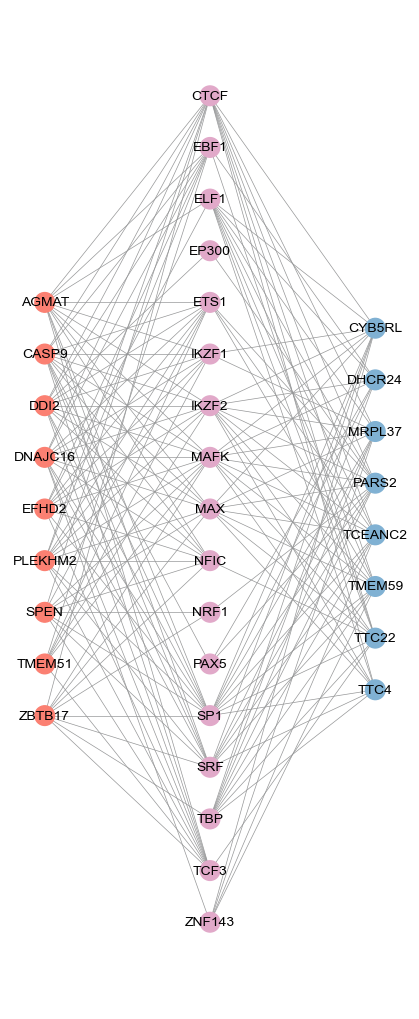

In [176]:
## n1, n2 : gene region
## n3 : SE region

n1 = as_region('chr1:15000000-16000000')
n2 = as_region('chr1:54000000-55000000')
n3 = as_region('chr1:116000000-117000000')

n1_genes, n2_genes, common_TFs = get_shared_TFs(n1=n1, n2=n2)
n1_genes_, n2_genes_, common_TFs_ = get_unique_genes(n1_genes, n2_genes, common_TFs)

df_1 = df_gm12878_TRN.loc[df_gm12878_TRN.Gene.isin(n1_genes_ ) & df_gm12878_TRN.TF.isin(common_TFs_)]
df_2 = df_gm12878_TRN.loc[df_gm12878_TRN.Gene.isin(n2_genes_ ) & df_gm12878_TRN.TF.isin(common_TFs_)]
df = pd.concat([df_1, df_2])
df['Region'] = ['n1'] * df_1.shape[0] + ['n2'] * df_2.shape[0]

## 过滤SE区域没有TF结合的
common_tfs = list(np.unique(df.TF))
tfs_ = []
for tf in common_tfs:
    if n3 in tf_ov_se_dict[tf]:
        tfs_.append(tf)

df = df.loc[df.TF.isin(tfs_)]

## 边信息
gene1_tf_edges = list(df.loc[df.Region == 'n1', ['Gene','TF']].apply(tuple, axis=1).values)
tf_gene2_edges = list(df.loc[df.Region == 'n2', ['TF', 'Gene']].apply(tuple, axis=1).values)
edges_dict = {0: gene1_tf_edges, 1:tf_gene2_edges}

## 节点信息
gene1 = list(np.unique(df.loc[(df.Region == 'n1'), 'Gene']))
gene2 = list(np.unique(df.loc[(df.Region == 'n2'), 'Gene']))
common_tfs = list(np.unique(df.TF))
gene1_num = len(gene1)
gene2_num = len(gene2)
common_tf_num = len(common_tfs)
node_color_map = ['#fb8072'] * gene1_num + ['#e1a9c9'] * common_tf_num + ['#80b1d3'] * gene2_num

## visualization
plt.figure(figsize=(4, 10))

# 网络离上下左右的距离
left, right, bottom, top = 0.1, 0.9, 0.01, 0.95
# layter_sizes可以自己调整
layer_sizes = [gene1_num, common_tf_num, gene2_num]
G = nx.Graph()
v_spacing = (top - bottom)/float(max(layer_sizes))
h_spacing = (right - left)/float(len(layer_sizes) - 1)

## 添加节点信息
nodes = gene1 + common_tfs + gene2
node_count = 0
for i, v in enumerate(layer_sizes):
    layer_top = v_spacing*(v-1)/2. + (top + bottom)/2.
    for j in range(v):
        G.add_node(nodes[node_count], pos=(left + i*h_spacing, layer_top - j*v_spacing))
        node_count += 1

## 添加边信息
for l in range(len(layer_sizes)-1):
    edges = edges_dict[l]
    for edge in edges:
        G.add_edge(edge[0], edge[1])

## 导出每个节点的位置信息
pos=nx.get_node_attributes(G, 'pos')
nx.draw(G, pos,
        node_color=node_color_map,
        with_labels=True,
        node_size=200, font_size=10, 
        edge_color='#969798', ## 边的颜色: 灰色
        width=0.5,
        # cmap=plt.cm.Dark2,  ## matplotlib调色板
        edge_cmap=plt.cm.Blues
       )
# plt.show()
plt.savefig('./MCI_TRN.pdf')

In [180]:
def plot_TRN_network(n1, n2, n3, region):
    ## n1, n2 : gene region
    ## n3 : SE region
    n1, n2, n3 = as_region(n1), as_region(n2), as_region(n3)
    n1_genes, n2_genes, common_TFs = get_shared_TFs(n1=n1, n2=n2)
    n1_genes_, n2_genes_, common_TFs_ = get_unique_genes(n1_genes, n2_genes, common_TFs)

    df_1 = df_gm12878_TRN.loc[df_gm12878_TRN.Gene.isin(n1_genes_ ) & df_gm12878_TRN.TF.isin(common_TFs_)]
    df_2 = df_gm12878_TRN.loc[df_gm12878_TRN.Gene.isin(n2_genes_ ) & df_gm12878_TRN.TF.isin(common_TFs_)]
    df = pd.concat([df_1, df_2])
    df['Region'] = ['n1'] * df_1.shape[0] + ['n2'] * df_2.shape[0]

    ## 过滤SE区域没有TF结合的
    common_tfs = list(np.unique(df.TF))
    tfs_ = []
    for tf in common_tfs:
        if n3 in tf_ov_se_dict[tf]:
            tfs_.append(tf)

    df = df.loc[df.TF.isin(tfs_)]

    ## 边信息
    gene1_tf_edges = list(df.loc[df.Region == 'n1', ['Gene','TF']].apply(tuple, axis=1).values)
    tf_gene2_edges = list(df.loc[df.Region == 'n2', ['TF', 'Gene']].apply(tuple, axis=1).values)
    edges_dict = {0: gene1_tf_edges, 1:tf_gene2_edges}

    ## 节点信息
    gene1 = list(np.unique(df.loc[(df.Region == 'n1'), 'Gene']))
    gene2 = list(np.unique(df.loc[(df.Region == 'n2'), 'Gene']))
    common_tfs = list(np.unique(df.TF))
    gene1_num = len(gene1)
    gene2_num = len(gene2)
    common_tf_num = len(common_tfs)
    node_color_map = ['#fb8072'] * gene1_num + ['#e1a9c9'] * common_tf_num + ['#80b1d3'] * gene2_num

    ## visualization
    plt.figure(figsize=(4, 10))

    # 网络离上下左右的距离
    left, right, bottom, top = 0.1, 0.9, 0.01, 0.95
    # layter_sizes可以自己调整
    layer_sizes = [gene1_num, common_tf_num, gene2_num]
    G = nx.Graph()
    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(len(layer_sizes) - 1)

    ## 添加节点信息
    nodes = gene1 + common_tfs + gene2
    node_count = 0
    for i, v in enumerate(layer_sizes):
        layer_top = v_spacing*(v-1)/2. + (top + bottom)/2.
        for j in range(v):
            G.add_node(nodes[node_count], pos=(left + i*h_spacing, layer_top - j*v_spacing))
            node_count += 1

    ## 添加边信息
    for l in range(len(layer_sizes)-1):
        edges = edges_dict[l]
        for edge in edges:
            G.add_edge(edge[0], edge[1])

    ## 导出每个节点的位置信息
    pos=nx.get_node_attributes(G, 'pos')
    nx.draw(G, pos,
            node_color=node_color_map,
            with_labels=True,
            node_size=200, font_size=10, 
            edge_color='#969798', ## 边的颜色: 灰色
            width=0.5,
            # cmap=plt.cm.Dark2,  ## matplotlib调色板
            edge_cmap=plt.cm.Blues
        )
    # plt.show()
    plt.savefig(f'./{region}_MCI_TRN.pdf')

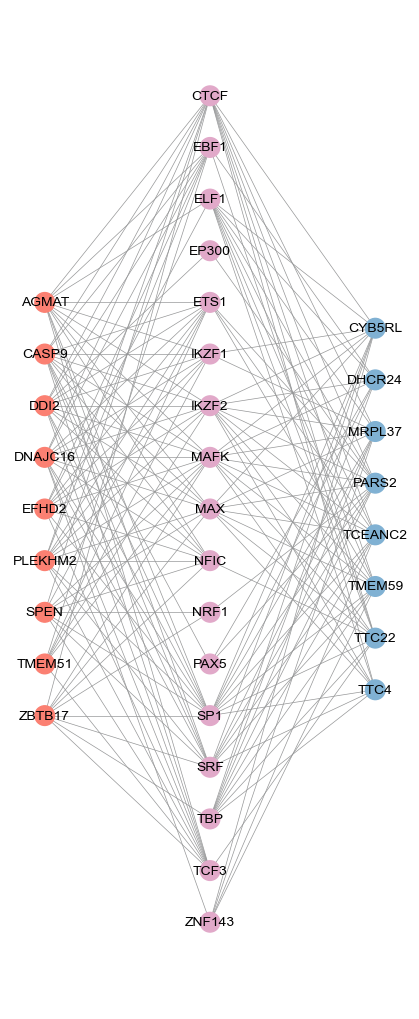

In [181]:
plot_TRN_network(n1='chr1:15000000-16000000', n2='chr1:54000000-55000000', n3='chr1:116000000-117000000', region='chr1_10mb-122mb')

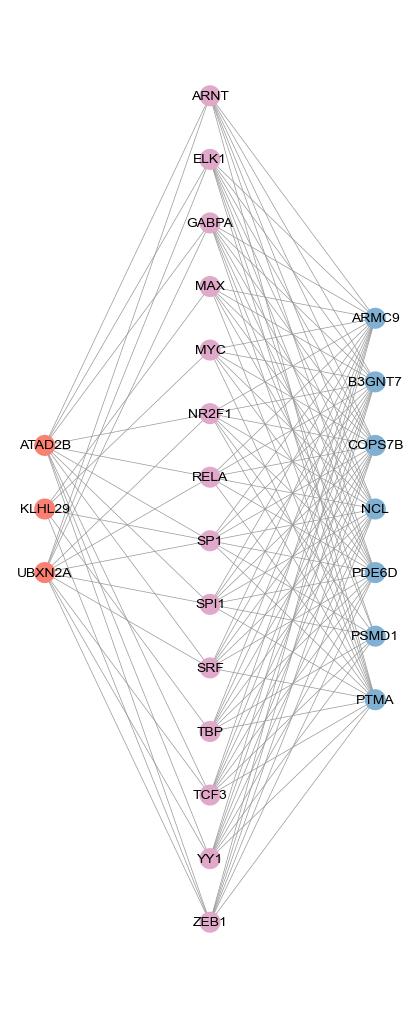

In [215]:
#  chr2:23000000-24000000,   chr2:540000000-55000000,  chr2:230000000-231000000
plot_TRN_network(n1='chr2:23000000-24000000', n2='chr2:231000000-232000000', n3='chr2:54000000-55000000', region='chr2_15mb-240mb')

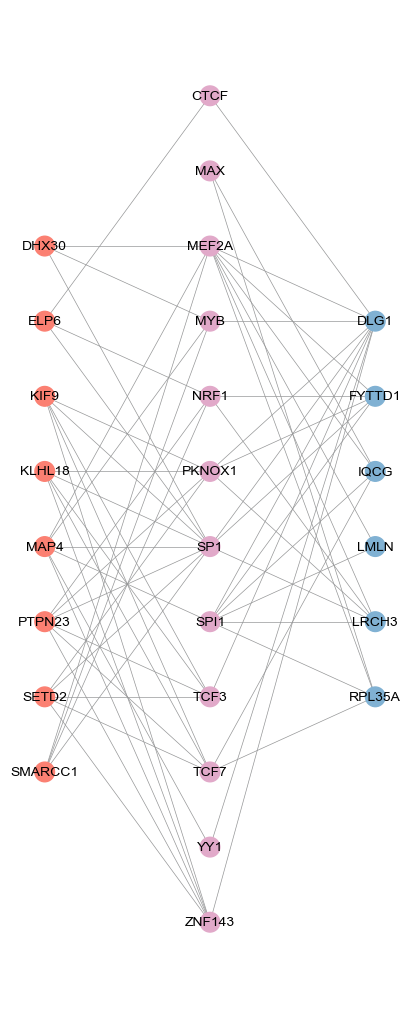

In [206]:
#  chr3:47000000-48000000,   chr3:119000000-120000000,  chr3:197000000-198000000
plot_TRN_network(n1='chr3:47000000-48000000', n2='chr3:197000000-198000000', n3='chr3:119000000-120000000', region='chr3_40mb-198mb')

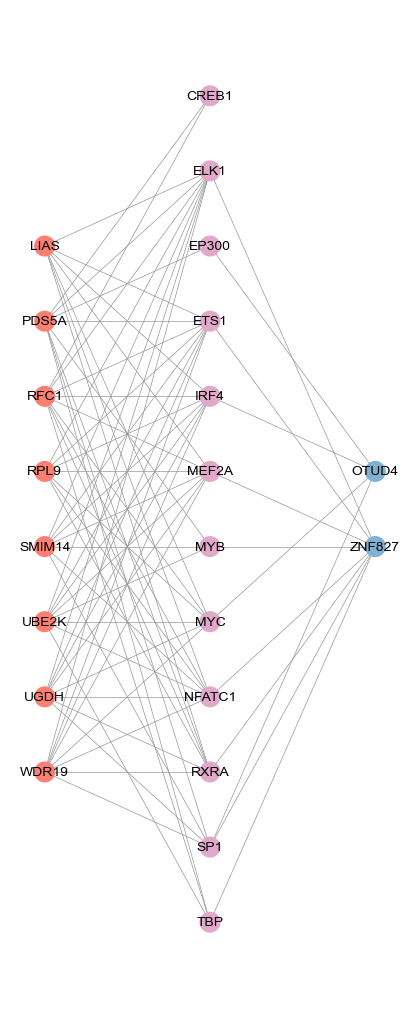

In [203]:
plot_TRN_network(n1='chr4:39000000-40000000', n2='chr4:145000000-146000000', n3='chr4:185000000-186000000', region='chr4_35mb-190mb')

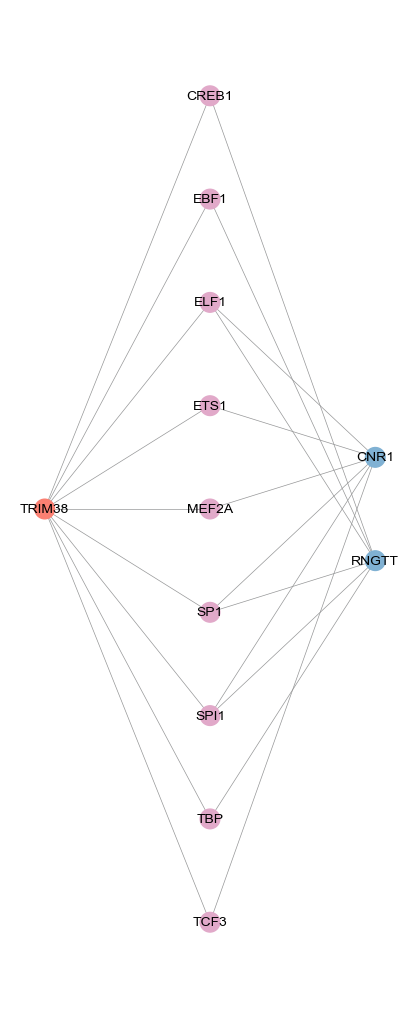

In [209]:
#  chr6:25000000-26000000,   chr6:88000000-89000000,    chr6:136000000-137000000
plot_TRN_network(n1='chr6:25000000-26000000', n2='chr6:88000000-89000000', n3='chr6:136000000-137000000', region='chr6_20mb-150mb')